In [1]:
import numpy as np 
import Physical_Const as phys
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq
from scipy.integrate import ode, odeint


import WD.neutrinos as nunu
import WD.CarbonFusion as eCC
import WD.EoS_ionee as EOS
import WD.ion_electron as ionee
import WD.ions as ion
import WD.electron_electron as ee
import WD.Cv_star as cv



#----Constants------

hbar     = phys.hbar
c        = phys.c
G        = phys.G
sigma    = phys.sigmaSB
me_mev   = phys.me
e        = phys.e
e_erg    = phys.e_erg
mevtoerg = phys.mevtoerg
mu       = phys.mu
kappaB   = phys.kappa
Msun     = phys.Msun
Rsun     = phys.Rsun

h        = hbar*(2.0*np.pi)
me       = me_mev * mevtoerg / c**2
c2       = c*c
arad     = 4.0*sigma / c
Tr       = me * c2 / kappaB
pi05     = np.sqrt(np.pi)
RBohr    = hbar**2 / (me*e_erg)
yr       = (364)*24*60*60
avo      = 1.0/mu


# ---Dimensions---
MA       = 2.0
Cgrav    = G * Msun / c2
Jdim     = G / c**3
mpl      = np.sqrt(hbar * c / G) # planck mass
Rdim     = ( mpl / me )**2.0 * hbar / (mpl * c)
Mdim     = Rdim / Cgrav

Sigma02  = np.power( c / Rdim,2.0) / G

Sigma    = np.power(me,4.0)*np.power(c,3.0)/(8.0*np.power(np.pi,2.0)*np.power(hbar,3.0))
SigmaP   = c2 * Sigma

Jadim    = 1e50
JJdim    = Jadim * Jdim  / Rdim**2
Tdim     = np.power(c**5 / ( 16.0**2 * np.pi**2 * G * sigma * Rsun**2) ,1.0/4.0)

rhobeta  = np.log10(3.9e10)

/home/laura/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
#---Algoritm first derivativa----------
def factorD(x,x0,x1,x2,x3):
    den = 3.0 * x * x - 2.0 * x * ( x1 + x2 + x3 ) + x1 * x2 + x2 * x3 + x1 * x3
    num = ( x0 - x1 ) * ( x0 - x2 ) * ( x0 - x3 )
    return den/num

def fit_derivative(xpoints,ypoints):
    NN    = len(xpoints)
    dd    = np.zeros(NN)
    dd[0] =   ( ypoints[1] - ypoints[0] ) / ( xpoints[1] - xpoints[0] )  
    dd[1]=    ( ypoints[3] - ypoints[0] ) / ( xpoints[3] - xpoints[0] ) 
   
    for i in range(2,NN-2):
        xi = xpoints[i]
        x0 = xpoints[i-2]
        x1 = xpoints[i-1]
        x2 = xpoints[i+1]
        x3 = xpoints[i+2]
        
        dd[i] = ypoints[i-2]*factorD(xi,x0,x1,x2,x3) + ypoints[i-1]*factorD(xi,x1,x0,x2,x3) + ypoints[i+1]*factorD(xi,x2,x0,x1,x3) + ypoints[i+2]*factorD(xi,x3,x0,x1,x2)
        
    dd[NN-2] =   ( ypoints[-2] - ypoints[-3] ) / ( xpoints[-2] - xpoints[-3] )  
    dd[NN-1] =   ( ypoints[-1] - ypoints[-2] ) / ( xpoints[-1] - xpoints[-2] )  
    
    return dd



In [4]:
#---read keplerian and static sequence-----
#file_kep = "MR_Relation/KepSeqWD_RMTF_mpl3.dat"
file_kep = "MR_Relation/KepSeqWD_Bf1E+07_1E+14.dat"
rhowd_kep,pwd_kep,Mstawd_kep,Rstawd_kep,Mrotwd_kep,Rrotwd_kep,Jwd_kep,Omegawd_kep = np.loadtxt(file_kep,usecols=(0,1,2,3,4,5,6,7),unpack=True)

#---read secular instability sequence-----
#file_SecInst = "MR_Relation/Secular_Instability_mpl.dat" 
#file_SecInst = "MR_Relation/SecularInstability_RMTF.dat"
file_SecInst = "MR_Relation/SecInsBfield_1E+07_1E+14.dat"
rhowd_seq,pwd_seq,Mstawd_seq,Rstawd_seq,Mrotwd_seq,Rrotwd_seq,Jwd_seq,Omegawd_seq,Qwd_seq,Omegakwd_seq=np.loadtxt(file_SecInst,usecols=(0,1,2,3,4,5,6,7,8,9),unpack=True)

Mmax_sta = Mstawd_kep.max()
Mmax_rot = Mrotwd_kep.max() 

i = 0
for rhoi in rhowd_seq:
    if rhoi>rhobeta:
        NNseq = i
        break;
    else:
        NNseq = 0
    i+=1

MMseq = Mrotwd_seq[NNseq]*Mdim

print("#############################################################")
print("Maximun static mass: ", Mmax_sta*Mdim )
print("Maximun rotating mass: ", Mmax_rot*Mdim )
print("#############################################################")

#----read constant mass sequence--------------------
#file_m = "MR_Relation/ConstMass_kuantay_139_2.dat"
file_m  = "MR_Relation/ConstMassBfield1E+07_1E+14_139.dat"
rhowd,pwd,Mstawd,Rstawd,Mrotwd,Rrotwd_eq,Rrotwd_pol,Jwd,Omegawd,Qwd,Omegakwd=np.loadtxt(file_m,usecols=(0,1,2,3,4,5,6,7,8,9,10),unpack=True)

Reqwd = (1.0/3.0)*(Rrotwd_pol + 2.0*Rrotwd_eq)


#############################################################
Maximun static mass:  1.8576308591525907
Maximun rotating mass:  2.1525988613210187
#############################################################


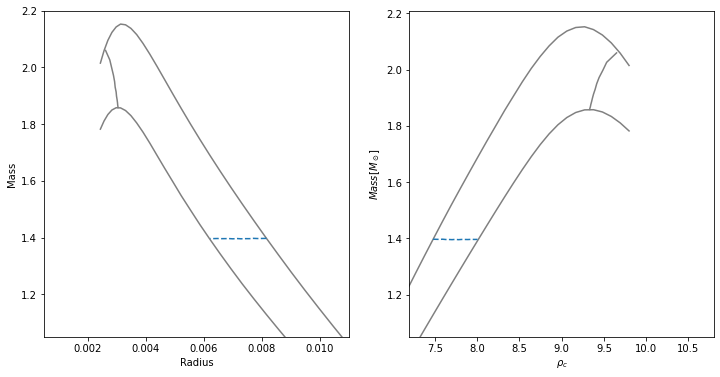

In [5]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.plot(Rstawd_kep*Rdim/Rsun, Mdim*Mstawd_kep, color="gray")
ax1.plot(Rrotwd_kep*Rdim/Rsun, Mdim*Mrotwd_kep, color="gray")
ax1.plot(Rrotwd_seq*Rdim/Rsun, Mdim*Mrotwd_seq, color="gray")


ax1.plot(Rrotwd_eq*Rdim/Rsun, Mrotwd*Mdim, ls="--" ) 

ax1.set_xlabel("Radius")
ax1.set_ylabel("Mass")

ax1.set_ylim(1.05,2.2)
ax1.set_xlim(0.0005,0.011)

ax2.plot(rhowd_kep, Mdim*Mstawd_kep, color="gray")
ax2.plot(rhowd_kep, Mdim*Mrotwd_kep, color="gray")
ax2.plot(rhowd_seq, Mdim*Mrotwd_seq, color="gray")


ax2.plot(rhowd, Mrotwd*Mdim, ls="--") 

ax2.set_xlabel("$\\rho_c$")
ax2.set_ylabel("$Mass [M_\\odot]$")

ax2.set_ylim(1.05,2.21)
ax2.set_xlim(7.2,10.8)

plt.show()

In [6]:
# Interpolation relations to integrate the evolution

Kep_Omega = interp1d( Mrotwd_kep*Mdim , Omegawd_kep )
Kep_Req   = interp1d( Mrotwd_kep*Mdim ,  Rrotwd_kep )
Kep_J     = interp1d( Mrotwd_kep*Mdim ,  Jwd_kep )
Kep_rho   = interp1d( Mrotwd_kep*Mdim ,  rhowd_kep )

Stt_rho   = interp1d( Mstawd_kep*Mdim, rhowd_kep  )

Masswd0   = 1.39
Omegawd_0 = Kep_Omega(Masswd0)
Reqwd_0   = Kep_Req(Masswd0)
jwd_0     = Kep_J(Masswd0)
rhowd_0   = Kep_rho(Masswd0)

print("The star stars at the keplerian sequence with Mass0 = ", Masswd0, " Msun \tOmega0 = ", Omegawd_0*Rdim/c, " \t Req0 = ", Reqwd_0*Rdim/Rsun)

Req_j    = interp1d( Jwd / JJdim , Reqwd / Reqwd_0 , kind='linear', bounds_error=False )    # Radius as function of angular momentum
Omega_j  = interp1d( Jwd / JJdim , Omegawd / Omegawd_0, kind='linear', bounds_error=False ) # Angular velocity as function of angular momentum
rho_j    = interp1d( Jwd / JJdim , rhowd , kind='linear', bounds_error=False )              # central density as function of angular momentum
DrhoDj_dats = fit_derivative( Jwd / JJdim , rhowd )
Drho_dj     = interp1d( Jwd / JJdim , DrhoDj_dats ,kind='linear', bounds_error=False ) # Derivative of density



The star stars at the keplerian sequence with Mass0 =  1.39  Msun 	Omega0 =  843.2909434171085  	 Req0 =  0.008217655983666621


# **Star Evolution**

The evolution of the star's angular momentum is:

$$\frac{d J}{dt} = − T_{dipole}  $$

The spin evolves due to the electromagnetic energy losees:
$$T_{dipole}= \frac{\mu_{WD}^2 \Omega^3}{c^3}(1+\sin^2(\theta)) $$

with $\mu_{WD}= B R^3$

In [7]:
def muWD(Bs,Rwd):
    #magnetic moment WD
    return Bs * Rwd**3.0 

def TdipIII(R_wd,Omega_wd):
    return ( R_wd**6.0 ) * ( Omega_wd**3.0 )

def AdipIII(tau, Omegawd_0, Rwd_0, Jwd_0,Bs):
    
    mu_wd = muWD(Bs,Rwd_0)
    
    return (1.0/ (3.0*c**3)) * (1.0 + np.sin(0.5*np.pi)**2) * ( Omegawd_0 ) **3.0 * mu_wd**2 * tau  / Jwd_0

def Torque_dip(t,y,ffx):
    #Equations to integrate
    jwd    = y[0]
    
    AAdip  = ffx[0]
    cc     = ffx[1]
    #tau   = ffx[2]
   
    Reqx   = Req_j( jwd )
    Omegax = Omega_j( jwd )
    
    if cc==0:
        # magnetic field constant
        ec1 = -np.log(10.0) * np.power(10.0,t) * AAdip * TdipIII(Reqx,Omegax)
    else:
        # magnetic flux conserved
        BB = 1.0 / Reqx
        ec1 = -np.log(10.0) * np.power(10.0,t) * AAdip * TdipIII(Reqx,Omegax) * BB**4
        
    return np.array( [ ec1 ] )

def RungheKut(t,y,h,fx):
    dsy1 = Torque_dip(t,y,fx)
    #print dsy1
    dsy2 = Torque_dip( t+h/2.0 , y + dsy1[0] * h / 2.0 , fx )
    #print dsy2
    dsy3 = Torque_dip( t + h / 2.0 , y + dsy2[0] * h / 2.0 , fx )
    #print dsy3
    dsy4 = Torque_dip( t + h  , y + dsy3[0] * h , fx )
    #print dsy4
    jnew = y[0] + (1.0/6.0) * h * ( dsy1[0] + 2.0 * ( dsy2[0] + dsy3[0] ) + dsy4[0] )
    
    return [ jnew ]



In [8]:
Bs0     = 1e6
jwd_dim = jwd_0 * JJdim * Rdim**2 / Jdim
tauD    = 1.0 / AdipIII(1.0, Omegawd_0*c / Rdim, Reqwd_0 * Rdim, jwd_dim , Bs0)
A0      = AdipIII(tauD,  Omegawd_0*c/Rdim, Reqwd_0 * Rdim, Jadim , Bs0) 

i = 0; 
dt = 1e-2
t0 = dt
yy0 = [ [ t0, Jwd[0]/JJdim ] ]

while rho_j( yy0[i][1] ) < rhobeta and yy0[i][1] > 1.01*Jwd[-1] / JJdim:
    yynew = RungheKut( t0 + i*dt, [yy0[i][1]], dt, [A0,0])
    #print(yynew)   
    i+=1
    yy0.append( [t0+i*dt,yynew[0]] )

yy1 = [ [ t0, Jwd[0]/JJdim ] ]
i=0
while rho_j( yy1[i][1] ) < rhobeta and yy1[i][1] > 1.01*Jwd.min() / JJdim:
    yynew = RungheKut( t0 + i*dt, [yy1[i][1]], dt, [A0,1])
    #print(yynew)   
    i+=1
    yy1.append( [t0+i*dt,yynew[0]] )
    
print(yy0[-1],yy1[-1])

[14.09, np.float64(0.1572469643809286)] [13.64, np.float64(0.15701448863737022)]


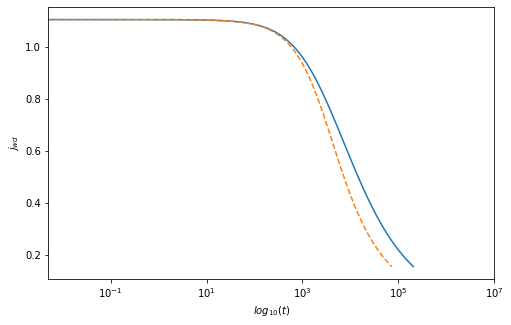

In [9]:
fig = plt.figure(figsize=(8,5))

plt.semilogx( np.power(10,np.array(yy0)[:,0]) * tauD / ( 1e6 * yr ), np.array(yy0)[:,1] )
plt.semilogx( np.power(10, np.array(yy1)[:,0]) * tauD / ( 1e6 * yr ) , np.array(yy1)[:,1], ls="--" )

plt.ylabel("$j_{wd}$")
plt.xlabel("$log_{10}(t$)")

plt.xlim(5e-3, 1e7)

plt.show()

In [10]:
#---cabon-ignition line--------
def tauCC(rhox,Txi,Abar,Zbar,XC):
    T = np.power(10.0,Txi)
    rho = np.power(10.0, rhox)
    return np.log10( nunu.QnuTotal(rho,T,Abar,Zbar) / eCC.QCC(rho,T,Zbar,Abar,XC) )

def funcCC(T,rhox):
  #  T = np.power(10.0,Txi)
    rho = np.power( 10.0 , rhox )
    return eCC.QCC(rho,T,6.0,12.0,0.5)


############ Ignition line------------
Tx = np.linspace( 7.0, 9.0, 50)
NN = len(Tx)
rhoCC = np.zeros(NN)

i=0
for xx in Tx:
    Tc = brentq(tauCC , 2.0 , 10.0 ,args=(xx,12.0,6.0,0.5))
    rhoCC[i] = Tc
    i+=1



In [11]:
xmass  = np.array( [0.5] )
aion   = np.array( [12.0] )
zion   = np.array( [6.0] )

rhoi     = 1e7
Tpon_dat = np.linspace(4.0,10.0,50)
NN = len(Tpon_dat)

cv_dat = np.zeros(NN)
Cvion  = np.zeros(NN)
Cve    = np.zeros(NN)
Cvie   = np.zeros(NN)
Cvii   = np.zeros(NN)
Cvee   = np.zeros(NN)

i=0
for ti in Tpon_dat:
    Ti = np.power(10.0,ti)
    cv_dat[i] = cv.cv_gas(rhoi,Ti,aion,xmass,zion)
    
    Ai = aion[0]
    Zi = zion[0]
    tr = kappaB*Ti/(me*c**2)

    Cve[i] = EOS.Cvienm(Ai,Zi,rhoi,tr)
    Cvion[i] = EOS.cv_ion()    
    
    Cvie[i] = ionee.Cvie(Ai,Zi,rhoi, Ti)
    Cvii[i] = ion.Cvii(Ai,Zi,rhoi,Ti) 
    Cvee[i] = ee.Cveenr(Ai,Zi,rhoi, Ti)
   
    i+=1


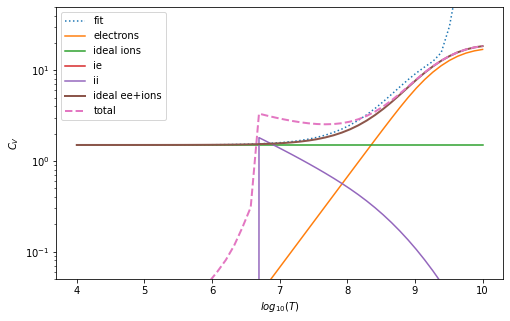

In [12]:
fig= plt.figure(figsize=(8,5))

plt.plot( Tpon_dat, cv_dat, ls=":",label="fit")

plt.plot( Tpon_dat, Cve , label="electrons")
plt.plot( Tpon_dat, Cvion , label="ideal ions")
plt.plot( Tpon_dat, Cvie, label="ie" )
plt.plot( Tpon_dat, Cvii, label="ii" )

plt.semilogy(  Tpon_dat,   Cvion + Cve , lw=2,label="ideal ee+ions" )
plt.semilogy(  Tpon_dat,  Cvii + Cvie + Cvion + Cve , lw=2,ls="--", label="total" )


plt.ylim(0.5e-1,5e1)

plt.xlabel("$log_{10}(T)$")
plt.ylabel("$C_V $")

plt.legend()

plt.show()


# **Star Evolution (with central temperature evoluation)**

The evolution of the star's angular momentum and the evoluation of the star central density is:

$$\frac{d J}{dt} = − T_{dipole}  $$
$$ \frac{dT}{dt} = \frac{P}{c_v\rho}\frac{d ln\rho}{dJ}\dot{J} + \frac{\epsilon_\nu-\epsilon_c}{c_v}$$

The spin evolves due to the electromagnetic energy losees:
$$T_{dipole}= \frac{\mu_{WD}^2 \Omega^3}{c^3}(1+\sin^2(\theta)) $$

with $\mu_{WD}= B R^3$



In [13]:
def cv_gas(A,Z,rho,T):
    
    tr    = kappaB * T / ( me * c2 )

    Cve   = EOS.Cvienm(A,Z,rho,tr)[0]
    Cvion = EOS.cv_ion()    
    
    #Cvie = ionee.Cvie(A,Z,rho, T)
    #Cvii = ion.Cvii(A,Z,rho,T)[0]
    #Cvee = ee.Cveenr(A,Z,rho, T)
    
    return Cve + Cvion
  
def Torque_dip(t,y,ffx):
    #Equations to integrate
    jwd   = y[0]
    Twd   = Tdim * y[1]
    
    AAdip = ffx[0]
    cc    = ffx[1]
    tau   = ffx[2] 
   
    #average atomic weight and charge
    ration = ( xmass / aion ).sum()
    XmassT = ( xmass * zion / aion ).sum()   
    abar   = 1.0e0 / ration
    zbar   = abar * XmassT

    Reqx      = Req_j( jwd )
    Omegax    = Omega_j( jwd )
    drhodj    = Drho_dj( jwd ) 
    logrhowdx = rho_j( jwd ) 
    rhowd     = np.power(10.0, logrhowdx)
    
    if cc==0:
        ec1 = -np.log(10.0) * np.power(10.0,t) * AAdip * TdipIII(Reqx,Omegax)
    else:
        BB  = 1.0 / Reqx
        ec1 = -np.log(10.0) * np.power(10.0,t) * AAdip * TdipIII(Reqx,Omegax) * BB**4
        
    cvv   = cv_gas( aion,zion, rhowd, Twd )
    qnunu = nunu.QnuTotal( rhowd, Twd, abar, zbar )
    qCC   = eCC.QCC( rhowd, Twd, zbar, abar, xmass[0] )
     
    ec2 = y[1] * drhodj * np.log(10.0) * ec1 / cvv + np.log(10.0) * np.power(10.0,t) * tau * abar * mu * (-qnunu + qCC )/( rhowd * kappaB * Tdim * cvv )
    
    return np.array( [ ec1, ec2 ] )

#Torque_dip(-5.0,[ Jwd[0]/JJdim, 1e8/Tdim ] ,[A0,0.0,tauD])

def Terms_eqs(t,y,ffx):
    AAdip = ffx[0]
    cc    = ffx[1]
    tau   = ffx[2]
    
    #average atomic weight and charge
    ration = ( xmass / aion ).sum()
    XmassT = ( xmass * zion / aion ).sum()   
    abar   = 1.0e0 / ration
    zbar   = abar * XmassT
        
    Reqx   = Req_j(y[0])
    Omegax = Omega_j(y[0])
    drhodj =  Drho_dj(y[0]) #Interp1D_ll( y[0], [ Jwd[j] / JJdim for j in range(NN)] , DrhoDj_dats )
    rhowdx =  rho_j(y[0])


    if cc==0:
        ec1 = -np.log(10.0)*np.power(10.0,t)*AAdip*TdipIII(Reqx,Omegax)
    else:
        BB = 1.0 / Reqx
        ec1 =  -np.log(10.0)*np.power(10.0,t)*AAdip*TdipIII(Reqx,Omegax) * BB**4
       
    #ec2 = y[1] * drhodj * np.log(10.0) * ec1 / cv_gas( np.power(10.0,rhowdx), Tdim*y[1], aion, xmass,zion)
    
    cvv   = cv_gas( aion,zion,  np.power(10.0,rhowdx), Tdim*y[1])
 
    term1 =  drhodj * np.log(10.0) * ec1 / cvv 
    term2 = np.log(10.0) * np.power(10.0,t) * tau * abar * mu * (  eCC.QCC(np.power(10.0,rhowdx),Tdim*y[1],zbar,abar,xmass[0])-nunu.QnuTotal(np.power(10.0,rhowdx),Tdim * y[1],abar,zbar)) / ( np.power(10.0,rhowdx) * kappaB * y[1] * Tdim * cvv )
    
    #print abar,zbar, term2, eCC.QCC(np.power(10.0,rhowdx),Tdim*y[1],zbar,abar,xmass[0]) , nunu.QnuTotal(np.power(10.0,rhowdx),Tdim * y[1],abar,zbar)
    #print cvv, kappa*y[1]*Tdim,  np.log(10.0) * np.power(10.0,t) * tau * abar * mu , np.power(10.0,rhowdx)
    return np.array([term1,term2])



In [15]:

Ting = interp1d( Tx, rhoCC ,kind='cubic', bounds_error=False ) # interpolation ignition line)

Temperature = ode(Torque_dip).set_integrator('dopri5',atol=1e-9)

if  Masswd0<Mmax_sta*Mdim:
    rholim = Stt_rho(Masswd0)
else:
    rholim = rhobeta


def Tevolution_2( y0, drr, rhowd0, Bs, cc):
    
    T0     = y0[1]*Tdim
    tauD   = 1.0 / AdipIII(1.0, Omegawd_0 * c / Rdim, Reqwd_0 * Rdim , jwd_0 * JJdim * Rdim**2 / Jdim, Bs)
    A0     = AdipIII(tauD, Omegawd_0 * c / Rdim, Reqwd_0 * Rdim, Jadim, Bs )

    t0     = -3
    rho_x  = rhowd0
    evol_1 = [ [np.power(10.0,t0)*tauD, rho_x, y0[0], Omegawd_0, y0[1] , Reqwd_0,0.0,0.0] ]
    i=1

    print( "Comparing density wiht ignition density:", rho_x, Ting(np.log10(y0[1]*Tdim) ) )
    Temperature.set_initial_value( y0,t0 ).set_f_params([A0, cc, tauD])
    print( "Ang. Mom \t density \t Temperatur \t Ing Tem ") 
    print( "------------------------------------------------ ")
    while Temperature.successful() and  rho_x < 0.99*rholim and rho_x< Ting ( np.log10(Temperature.y[1]*Tdim) ):
        told = Temperature.t
        Temperature.integrate(Temperature.t+drr)

        ywd = Temperature.y[0]
        Reqnew    = Req_j(ywd)
        Omegaxnew = Omega_j(ywd)
        rho_x     = rho_j(ywd)
       
        delta_time = Temperature.t - told
        termss = Terms_eqs(Temperature.t,Temperature.y,[A0, cc, tauD])
      
        evol_1.append( [ np.power(10.0,(Temperature.t))*tauD , rho_x , Temperature.y[0] , Omegawd_0 * Omegaxnew ,
                        Temperature.y[1], Reqnew * Reqwd_0, termss[0]*delta_time, termss[1]*delta_time])
        
        print(ywd, rho_x, np.log10(Temperature.y[1]*Tdim), Ting ( np.log10(Temperature.y[1]*Tdim) ) )
    
    return evol_1

In [16]:
x_B = np.linspace(8,10,10)

Bs0  = np.power(10.0,x_B[0])

tauD = 1.0 / AdipIII( 1.0, Omegawd_0*c/Rdim, Reqwd_0*Rdim, jwd_0*JJdim*Rdim**2/Jdim , Bs0)
A0   = AdipIII( tauD, Omegawd_0*c/Rdim, Reqwd_0*Rdim, Jadim,Bs0 )
    
Evol1 = Tevolution_2( [ Jwd[0]/JJdim, 1e8/Tdim ] , 5e-1, rhowd_0, Bs0 , 0.0 )

Comparing density wiht ignition density: 7.468246407754717 9.896469790922866
Ang. Mom 	 density 	 Temperatur 	 Ing Tem 
------------------------------------------------ 
1.1035110950121225 7.479300430000001 8.0 9.896469790922866
1.1035110950121203 7.479300430000004 8.0 9.896469790922866
1.1035110950121134 7.479300430000011 8.0 9.896469790922866
1.1035110950120917 7.479300430000035 8.000000000000002 9.896469790922865
1.1035110950120228 7.4793004300001105 8.000000000000005 9.896469790922861
1.1035110950118054 7.479300430000349 8.00000000000002 9.896469790922854
1.1035110950111182 7.479300430001104 8.00000000000006 9.89646979092283
1.1035110950089446 7.479300430003492 8.000000000000192 9.89646979092275
1.1035110950020715 7.479300430011042 8.00000000000061 9.8964697909225
1.1035110949803364 7.479300430034917 8.000000000001926 9.896469790921707
1.1035110949116038 7.479300430110419 8.000000000006091 9.8964697909192
1.1035110946942526 7.4793004303491735 8.000000000019261 9.896469790911274
1.1

Text(0.5, 0, 'time [Myr]')

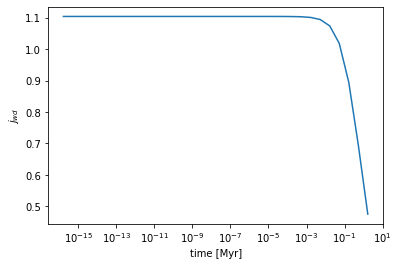

In [19]:
plt.semilogx( np.array(Evol1)[:,0]/(1e6*yr), np.array(Evol1)[:,2])

plt.ylabel("$j_{wd}$")
plt.xlabel("time [Myr]")

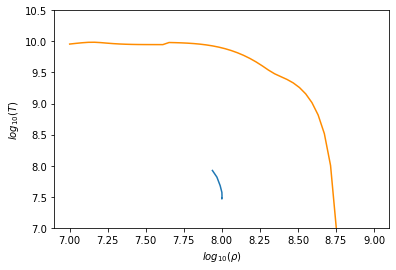

In [20]:
fig= plt.figure()

plt.plot(Tx,rhoCC, color="DarkOrange" )

plt.plot(  np.log10( np.array(Evol1)[:,4]*Tdim), np.array(Evol1)[:,1] )


plt.xlabel("$log_{10}(\\rho)$")
plt.ylabel("$log_{10}(T)$")

plt.ylim(7,10.5)


plt.show()